In [ ]:
pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.4/28.4 MB 31.7 MB/s eta 0:00:00


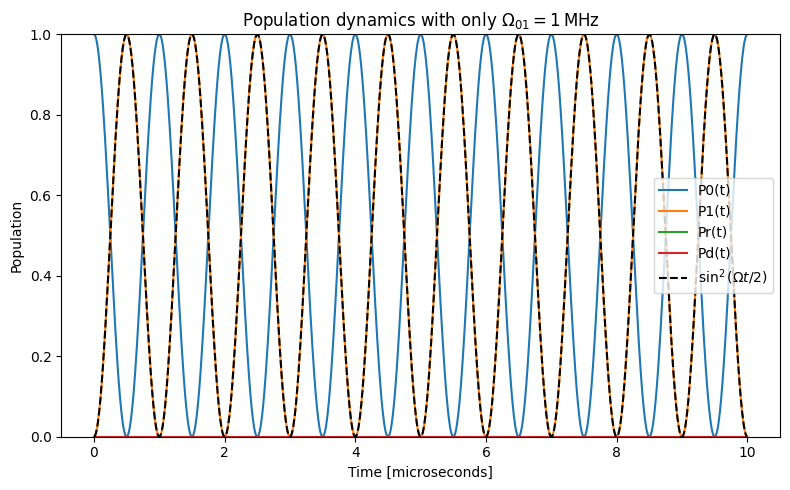

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, mesolve

# === 1) Parameters ===
Omega01_MHz = 1.0                   # 1 MHz
gamma_r = 1/(5e-6)                  # 1/(5 microseconds) = 2e5 1/s
b0r = 1/16
b1r = 1/16
bdr = 7/8

# === 2) Time range ===
tmax = 10e-6
num_points = 1000
tlist = np.linspace(0, tmax, num_points)

# === 3) Basis states, projectors ===
ket0 = basis(4, 0)
ket1 = basis(4, 1)
ketr = basis(4, 2)
ketd = basis(4, 3)

proj0 = ket0*ket0.dag()
proj1 = ket1*ket1.dag()
projr = ketr*ketr.dag()
projd = ketd*ketd.dag()

# === 4) Hamiltonian ===
H_01 = ket0*ket1.dag() + ket1*ket0.dag()
H = 0.5 * Omega01 * H_01

# === 5) Lindblad operators ===
L0 = np.sqrt(b0r*gamma_r) * (ket0*ketr.dag())
L1 = np.sqrt(b1r*gamma_r) * (ket1*ketr.dag())
Ld = np.sqrt(bdr*gamma_r) * (ketd*ketr.dag())
c_ops = [L0, L1, Ld]

# === 6) Solve the master equation, starting in |0> ===
rho0 = proj0
e_ops = [proj0, proj1, projr, projd]

result = mesolve(H, rho0, tlist, c_ops, e_ops)

# === 7) Expectation values (populations) ===
p0 = result.expect[0]
p1 = result.expect[1]
pr = result.expect[2]
pd = result.expect[3]

# Rabi formula for a two-level system
def P1_rabi(t, Omega):
    return np.sin(0.5*Omega*t)**2

p1_rabi = [P1_rabi(tt, Omega01) for tt in tlist]

# === 8) Plot results ===
plt.figure(figsize=(8,5))
plt.plot(tlist*1e6, p0, label='P0(t)')
plt.plot(tlist*1e6, p1, label='P1(t)')
plt.plot(tlist*1e6, pr, label='Pr(t)')
plt.plot(tlist*1e6, pd, label='Pd(t)')
plt.plot(tlist*1e6, p1_rabi, 'k--', label=r'$\sin^2(\Omega t / 2)$')

plt.title("Population dynamics with only $\Omega_{01} = 1\,\mathrm{MHz}$")
plt.xlabel("Time [microseconds]")
plt.ylabel("Population")
plt.ylim([0,1])
plt.legend()
plt.tight_layout()
plt.show()


For “Is there any decay?” — because
Ω
r
​
 (t)=0, no population flows into
∣r⟩. Consequently, even though we have Lindblad operators for
∣r⟩ decay, that Lindblad path remains unused. We should see no noticeable decay of
∣1⟩ population.